# Access to Care: Opioid Overdose Risk & Treatment Availability
### Capstone Analysis Notebook

This notebook answers four research questions using county-level data from CDC WONDER, SAMHSA, and the U.S. Census Bureau ACS (2018–2024).

**Research Questions:**
1. How do socioeconomic factors (income, poverty, unemployment) correlate with opioid overdose mortality rates?
2. Are treatment facilities distributed in proportion to overdose mortality rates?
3. Does treatment access correlate with lower overdose mortality?
4. Which counties show the largest gaps between overdose risk and treatment availability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [3]:
#set a theme for all visuals
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE  = 'viridis'
ACCENT   = '#2c7bb6'
WARN     = '#d7191c'
FIG_SIZE = (10, 6)

In [5]:
df = pd.read_csv('../data/master_df.csv')
df.head()

,county_state,fips,deaths,Population,median_income,population,poverty_rate,unemployment_rate,facility_count,overdose_rate,facility_rate
0,"Abbeville County, SC",45001.0,45.0,171168,52935.0,24420.0,15.7,4.0,NaN,184.275184,NaN
1,"Acadia Parish, LA",22001.0,151.0,413278,45562.0,56955.0,25.0,7.7,1.0,265.121587,1.755772
2,"Accomack County, VA",51001.0,55.0,230053,58993.0,33335.0,13.9,3.4,2.0,164.991750,5.999700
3,"Ada County, ID",16001.0,676.0,3537262,91502.0,518935.0,8.3,3.1,36.0,130.266796,6.937285
4,"Adair County, IA",0.0,NaN,NaN,68092.0,7460.0,9.5,4.0,NaN,NaN,NaN


In [6]:
# Rename duplicate population columns 
df = df.rename(columns={
    'Population': 'population_7yr',   # cumulative 7-year CDC denominator
    'population': 'population'        # single-year population
})

# Drop territory rows with bad FIPS
df = df[df['fips'] != '00000'].copy()

# Extract state 
df['state'] = df['county_state'].str.extract(r',\s*([A-Z]{2})$')

# gap score (used in Q4)
df['gap_score'] = df['overdose_rate'] - df['facility_rate']

# Working subset: rows with all analytical columns present
cols_needed = ['overdose_rate', 'poverty_rate', 'median_income',
               'unemployment_rate', 'facility_rate', 'facility_count', 'gap_score']
complete = df.dropna(subset=cols_needed).copy()

print(f'Total counties: {len(df):,}')
print(f'Complete rows for analysis: {len(complete):,}')
df.head(3)

Total counties: 3,314
Complete rows for analysis: 1,887


,county_state,fips,deaths,population_7yr,median_income,population,poverty_rate,unemployment_rate,facility_count,overdose_rate,facility_rate,state,gap_score
0,"Abbeville County, SC",45001.0,45.0,171168,52935.0,24420.0,15.7,4.0,NaN,184.275184,NaN,SC,NaN
1,"Acadia Parish, LA",22001.0,151.0,413278,45562.0,56955.0,25.0,7.7,1.0,265.121587,1.755772,LA,263.365815
2,"Accomack County, VA",51001.0,55.0,230053,58993.0,33335.0,13.9,3.4,2.0,164.991750,5.999700,VA,158.992050


---
## Q1 — How do socioeconomic factors correlate with opioid overdose mortality?

We examine three socioeconomic variables — median household income, poverty rate, and unemployment rate — against the county-level overdose rate (per 100k, age-adjusted). We use both a correlation heatmap and individual scatter plots with regression lines.

In [7]:
corr_cols = {
    'overdose_rate':    'Overdose Rate',
    'median_income':    'Median Income',
    'poverty_rate':     'Poverty Rate',
    'unemployment_rate':'Unemployment Rate',
    'facility_rate':    'Facility Rate',
    'gap_score':        'Gap Score'
}

In [8]:
corr_df = complete[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_df.corr()

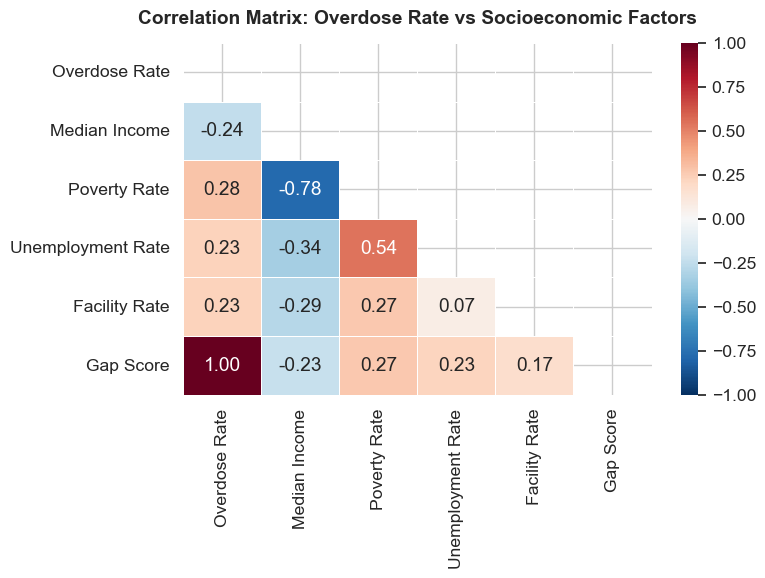

Saved: q1_correlation_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix: Overdose Rate vs Socioeconomic Factors', pad=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q1_correlation_heatmap.png')

In [10]:
socio_vars = [
    ('median_income',     'Median Household Income ($)',  False),
    ('poverty_rate',      'Poverty Rate (%)',              True),
    ('unemployment_rate', 'Unemployment Rate (%)',         True),
]

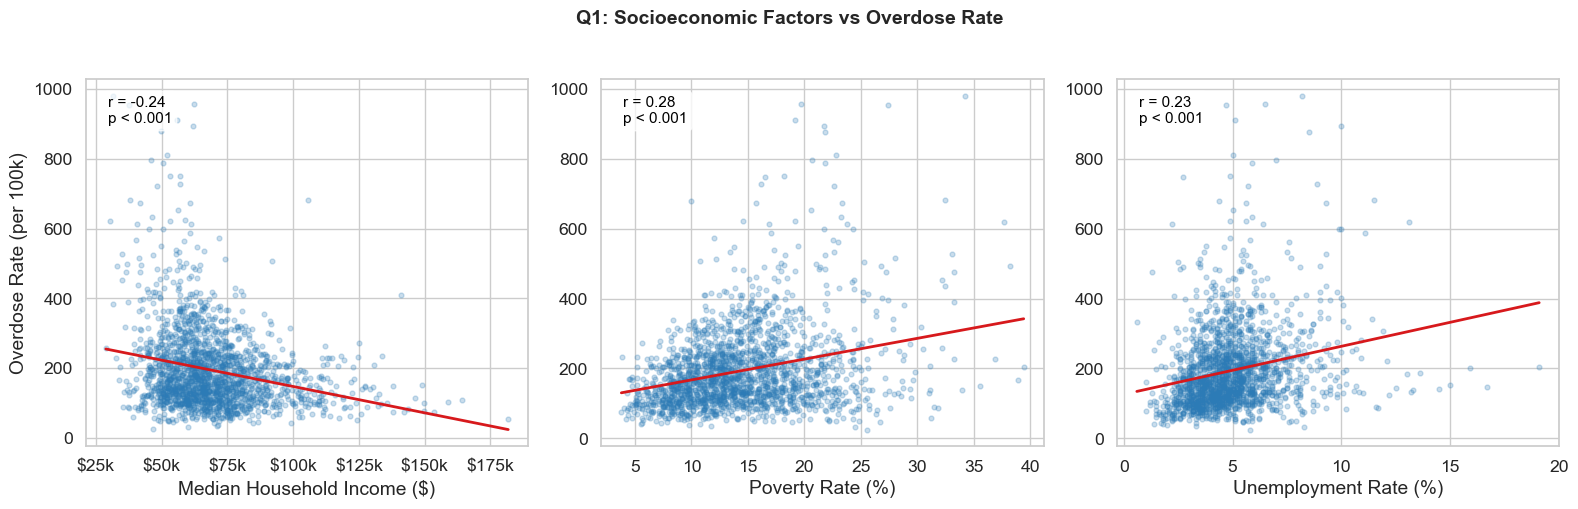

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q1: Socioeconomic Factors vs Overdose Rate', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, label, positive_expected) in zip(axes, socio_vars):
    x = complete[col]
    y = complete['overdose_rate']

    # Scatter
    ax.scatter(x, y, alpha=0.25, s=12, color=ACCENT)

    # Regression line
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color=WARN, linewidth=2)

    # Annotate with r and p-value
    p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.annotate(f'r = {r:.2f}\n{p_str}',
                xy=(0.05, 0.88), xycoords='axes fraction',
                fontsize=11, color='black',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_xlabel(label)
    ax.set_ylabel('Overdose Rate (per 100k)' if ax == axes[0] else '')

    # Format x-axis for income
    if col == 'median_income':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

plt.tight_layout()

In [12]:
plt.savefig('../outputs/q1_socioeconomic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q1_socioeconomic_scatter.png')

<Figure size 640x480 with 0 Axes>

Saved: q1_socioeconomic_scatter.png


In [13]:
print('Pearson correlations with Overdose Rate:\n')
for col, label, _ in socio_vars:
    r, p = stats.pearsonr(complete[col], complete['overdose_rate'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {label:<30} r = {r:+.3f}  {sig}')

Pearson correlations with Overdose Rate:

  Median Household Income ($)    r = -0.244  ***
  Poverty Rate (%)               r = +0.285  ***
  Unemployment Rate (%)          r = +0.228  ***


## Q2 — Are treatment facilities distributed in proportion to overdose mortality?

If the healthcare system were responding efficiently to need, we'd expect counties with higher overdose rates to also have more treatment facilities per capita. We test this by plotting overdose rate vs facility rate and examining the distribution.

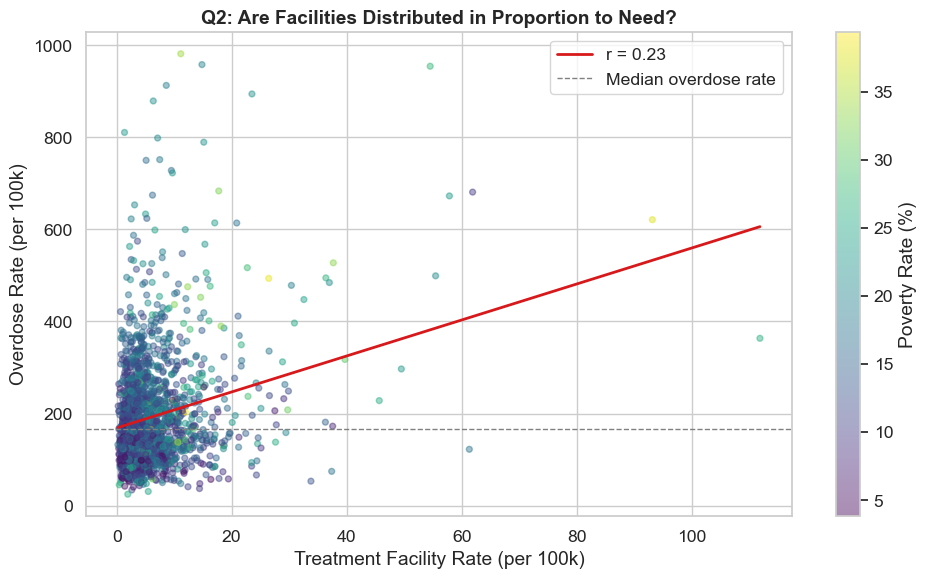

Saved: q2_facility_vs_overdose.png


In [14]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

scatter = ax.scatter(
    complete['facility_rate'],
    complete['overdose_rate'],
    c=complete['poverty_rate'],
    cmap=PALETTE,
    alpha=0.45, s=18
)
plt.colorbar(scatter, ax=ax, label='Poverty Rate (%)')

# Regression
m, b, r, p, _ = stats.linregress(complete['facility_rate'], complete['overdose_rate'])
x_line = np.linspace(complete['facility_rate'].min(), complete['facility_rate'].max(), 200)
ax.plot(x_line, m * x_line + b, color=WARN, linewidth=2, label=f'r = {r:.2f}')

# Reference line: equal supply/demand (facilities proportional to overdose rate)
ax.axhline(complete['overdose_rate'].median(), color='gray', linestyle='--',
           linewidth=1, label='Median overdose rate')

ax.set_xlabel('Treatment Facility Rate (per 100k)')
ax.set_ylabel('Overdose Rate (per 100k)')
ax.set_title('Q2: Are Facilities Distributed in Proportion to Need?', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/q2_facility_vs_overdose.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q2_facility_vs_overdose.png')

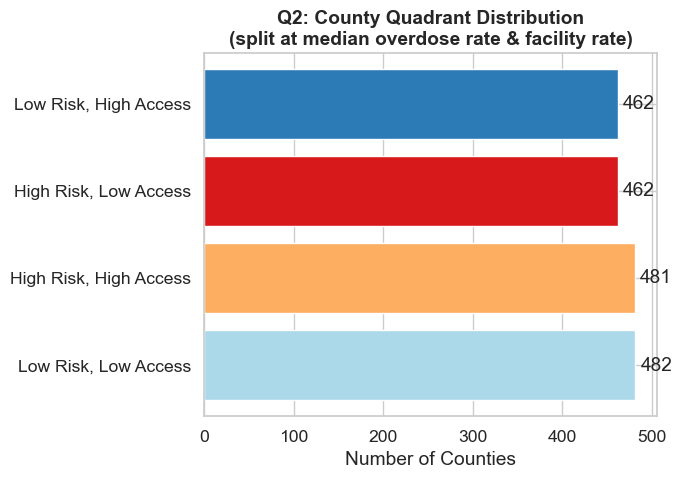


Quadrant counts:
quadrant
Low Risk, Low Access      482
High Risk, High Access    481
High Risk, Low Access     462
Low Risk, High Access     462


In [15]:
# Q2b: Quadrant analysis
# Divide counties into four quadrants by median overdose rate & facility rate
od_med  = complete['overdose_rate'].median()
fac_med = complete['facility_rate'].median()

def quadrant(row):
    hi_od  = row['overdose_rate'] > od_med
    hi_fac = row['facility_rate'] > fac_med
    if hi_od and not hi_fac:  return 'High Risk, Low Access'    # worst
    if hi_od and hi_fac:      return 'High Risk, High Access'
    if not hi_od and hi_fac:  return 'Low Risk, High Access'
    return                           'Low Risk, Low Access'

complete['quadrant'] = complete.apply(quadrant, axis=1)
quad_counts = complete['quadrant'].value_counts()

colors = {
    'High Risk, Low Access':  '#d7191c',
    'High Risk, High Access': '#fdae61',
    'Low Risk, Low Access':   '#abd9e9',
    'Low Risk, High Access':  '#2c7bb6',
}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    quad_counts.index,
    quad_counts.values,
    color=[colors[q] for q in quad_counts.index]
)
ax.bar_label(bars, padding=4)
ax.set_xlabel('Number of Counties')
ax.set_title('Q2: County Quadrant Distribution\n(split at median overdose rate & facility rate)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q2_quadrant_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQuadrant counts:')
print(quad_counts.to_string())

## Q3 — Does treatment access correlate with lower overdose mortality?

We compare overdose rates between counties with above- and below-median facility rates, and use a multivariate regression to control for socioeconomic confounders.

> **Note:** This analysis is correlational, not causal. Counties with more facilities may differ in other ways (urbanicity, income, state policy) that also affect overdose mortality.

/var/folders/h8/51mqc9v517x00_mhcb5s7ncw0000gn/T/ipykernel_2028/4238754014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


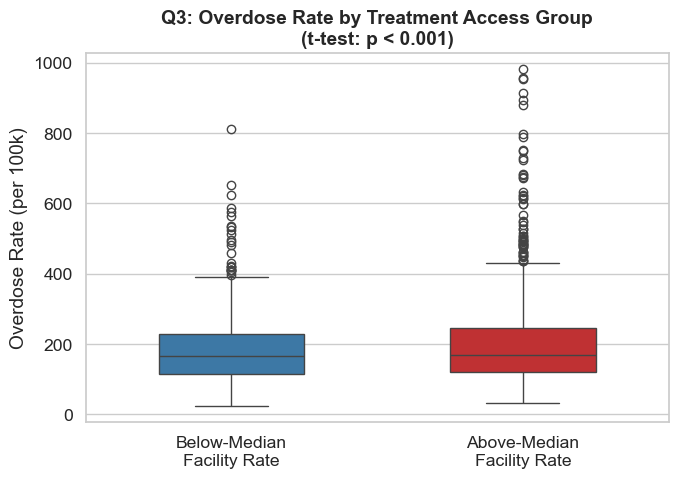

Mean overdose rate — Above-median access: 205.1
Mean overdose rate — Below-median access: 182.6
t = 4.27, p < 0.001


In [16]:
# ── Q3a: Box plot — overdose rate by access group ─────────────────────────
complete['access_group'] = np.where(
    complete['facility_rate'] >= fac_med,
    'Above-Median\nFacility Rate',
    'Below-Median\nFacility Rate'
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=complete,
    x='access_group', y='overdose_rate',
    palette=['#2c7bb6', '#d7191c'],
    width=0.5, ax=ax
)

# T-test
high = complete.loc[complete['access_group'].str.startswith('Above'), 'overdose_rate']
low  = complete.loc[complete['access_group'].str.startswith('Below'), 'overdose_rate']
t, p = stats.ttest_ind(high, low)
p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'

ax.set_title(f'Q3: Overdose Rate by Treatment Access Group\n(t-test: {p_str})', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Overdose Rate (per 100k)')

plt.tight_layout()
plt.savefig('../outputs/q3_access_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean overdose rate — Above-median access: {high.mean():.1f}')
print(f'Mean overdose rate — Below-median access: {low.mean():.1f}')
print(f't = {t:.2f}, {p_str}')

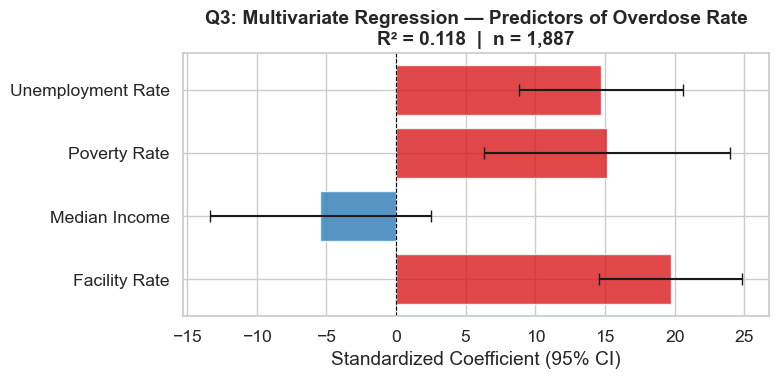

                            OLS Regression Results                            
Dep. Variable:          overdose_rate   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     62.94
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           5.47e-50
Time:                        13:49:03   Log-Likelihood:                -11509.
No. Observations:                1887   AIC:                         2.303e+04
Df Residuals:                    1882   BIC:                         2.306e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        193.8305      2.484     78.021      0.0

In [17]:
# Q3b: Multivariate OLS regression
# Controls for income, poverty, and unemployment so we can isolate the independent effect of facility access on overdose rate.
try:
    import statsmodels.api as sm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    import statsmodels.api as sm

reg_df = complete[['overdose_rate', 'facility_rate', 'median_income',
                    'poverty_rate', 'unemployment_rate']].dropna()

# Standardize predictors so coefficients are comparable
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(reg_df.drop(columns='overdose_rate'))
X = sm.add_constant(X_scaled)
y = reg_df['overdose_rate']

model = sm.OLS(y, X).fit()

# Plot coefficients
coef_names = ['Intercept', 'Facility Rate', 'Median Income',
              'Poverty Rate', 'Unemployment Rate']
coefs  = model.params[1:]   # skip intercept
errors = model.bse[1:]
names  = coef_names[1:]

fig, ax = plt.subplots(figsize=(8, 4))
colors_coef = [WARN if c > 0 else ACCENT for c in coefs]
bars = ax.barh(names, coefs, xerr=errors * 1.96,
               color=colors_coef, alpha=0.8, capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardized Coefficient (95% CI)')
ax.set_title(f'Q3: Multivariate Regression — Predictors of Overdose Rate\n'
             f'R² = {model.rsquared:.3f}  |  n = {len(y):,}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/q3_regression_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

print(model.summary())

## Q4 — Which counties show the largest gaps between overdose risk and treatment availability?

We compute a composite risk score and identify the most underserved counties — those where overdose mortality is high relative to treatment access.